In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
%load_ext autoreload
%autoreload 1
%aimport cowaver.utils
%aimport cowaver.datasets
%aimport cowaver.datamodules
%aimport cowaver.models
%aimport cowaver.modules
%aimport cowaver.checkpoints

### Constantes

In [3]:
from pathlib import Path

# Rutas a los datos
tiny_emnist_filename = Path("../data/tiny-emnist-26.tar.xz")
tiny_kalulu_filename = Path("../data/tiny-kalulu-200.tar.xz")
tiny_phones_filename = Path("../data/tiny-phones-200.tar.xz")
tiny_letter_filename = Path("../data/tiny-letter-26.tar.xz")
kalulu_words_filename = Path("../data/kalulu-words.tar.xz")
kalulu_phonemes_filename = Path("../data/kalulu-phonemes.tar.xz")

data_path = Path("data")  # Carpeta donde se descomprimirán los datos

num_layers_in_wav2vec2 = 12

### Funciones utilitarias

### Funciones de graficado

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from cowaver.utils import AUDIO_SAMPLE_RATE
from cowaver.models import TrainHistory, TestResults
from cowaver.datasets import EMNIST_STD, EMNIST_MEAN

def plot_waveform(waveform, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if waveform.dim() == 2:
        waveform = waveform[0]

    waveform = waveform.detach().cpu()
    time = torch.arange(len(waveform)) / AUDIO_SAMPLE_RATE

    ax.plot(time.numpy(), waveform.numpy())
    ax.set_title("Forma de onda")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    if should_show:
        plt.show()

def plot_image(image, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if image.dim() == 5:
        image = image[0, 0]      # [S,B,C,H,W] -> primera imagen
    elif image.dim() == 4:
        image = image[0]         # [B,C,H,W] -> primera imagen
    elif image.dim() != 3:
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image.detach().cpu()

    mean = torch.tensor(EMNIST_MEAN, device=image.device).view(3, 1, 1)
    std = torch.tensor(EMNIST_STD, device=image.device).view(3, 1, 1)
    image = image * std + mean

    ax.imshow(image.clamp(0, 1).permute(1, 2, 0))
    ax.set_title("Imagen")
    ax.axis("off")

    if should_show:
        plt.show()

def plot_train_history(train_history: TrainHistory, subfig=None):
    if subfig is None:
        _, ax = plt.subplots(figsize=(8, 3), layout="constrained")
        should_show = True
    else:
        ax = subfig.subplots()
        should_show = False
    epochs = range(1, train_history.num_epochs + 1)
    ax.plot(epochs, train_history.train_losses, label="Entrenamiento")
    ax.plot(epochs, train_history.val_losses, "r", label="Validación")
    ax.set_title("Training vs Validation Loss")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
    if should_show:
        plt.show()

def plot_logits(logits, classes, subfig=None):
    if subfig is None:
        fig = plt.figure(figsize=(8, 3), layout="constrained")
        subfig = fig.subfigures()
        should_show = True
    else:
        should_show = False

    topk_values, topk_indices = torch.topk(logits.detach().cpu().squeeze(), k=5)
    topk_classes = [classes[i] for i in topk_indices.cpu().numpy()]

    logits, classes = topk_values, topk_classes
    
    values = logits.squeeze().numpy()
    order = np.argsort(values)[::-1]
    sorted_classes  = [classes[i] for i in order]
    sorted_values = values[order]

    ax = subfig.subplots()
    ax.plot(sorted_classes, sorted_values, marker='o')
    ax.set_title("Logits")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    if should_show:
        plt.show()

def plot_test_results(test_results: TestResults | list):
    plt.figure(figsize=(10, 3), layout="constrained")
    if isinstance(test_results, TestResults):
        plt.bar(["top1", "top3", "top5"], [test_results.top1, test_results.top3, test_results.top5])
    else:
        plt.plot(range(len(test_results)), list(map(lambda x: x.top1, test_results)), 'r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top3, test_results)), '--r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top5, test_results)), ':r')
        plt.legend(["top1", "top3", "top5"])
    plt.ylim(0.0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

def plot_activation(activation, ax=None, vmin=-3, vmax=3):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if activation.dim() == 4:
        activation = activation[0, 0]
    elif activation.dim() == 3:
        activation = activation[0]
    elif activation.dim() != 2:
        raise ValueError(f"Unexpected activation shape: {activation.shape}")

    activation = activation.detach().cpu()

    im = ax.imshow(
        activation.numpy(),
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_title("Activación")
    ax.set_xlabel("Dimensión")
    ax.set_ylabel("Ventana")
    ax.set_xticks([0, activation.size(1) - 1])
    ax.set_yticks([0, activation.size(0) - 1])

    if should_show:
        plt.colorbar(im, ax=ax)
        plt.show()

    return im
        
def plot_mel(mel, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if mel.dim() == 4:
        mel = mel[0, 0]       # [B,1,mel_bins,T]
    elif mel.dim() == 3:
        mel = mel[0]          # [B,mel_bins,T] o [1,mel_bins,T]
    elif mel.dim() != 2:
        raise ValueError(f"Unexpected mel shape: {mel.shape}")

    mel = mel.detach().cpu()

    ax.imshow(
        mel.numpy(),
        cmap="coolwarm",
        aspect="auto"
    )

    ax.set_title("Mel")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Mel bins")
    ax.set_xticks([0, mel.size(1) - 1])
    ax.set_yticks([0, mel.size(0) - 1])

    if should_show:
        plt.show()


def plot_pca(scores: torch.Tensor, labels: list | None):
    """Grafica una proyección PCA bidimensional.

    Parameters
    ----------
    scores: Tensor
        Tensor de forma [B, q], donde B es el número de ejemplos.
        Se grafican las dos primeras componentes.

    labels: list | None
        Lista opcional de etiquetas, una por ejemplo. Si se proporciona,
        debe tener largo B.
    """
    
    scores = scores.detach().cpu()

    if labels is not None and len(labels) != scores.size(0):
        raise ValueError("labels debe tener el mismo largo que scores.")
    
    plt.figure(figsize=(6, 6))
    plt.scatter(scores[:, 0], scores[:, 1])
    if labels is not None:
        for i, label in enumerate(labels):
            plt.text(scores[i, 0].item(), scores[i, 1].item(), label, fontsize=9)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA")
    plt.grid(True)
    plt.show()

## Preparación del entorno

In [5]:
from cowaver.utils import descomprimir_archivo

tiny_emnist_path = descomprimir_archivo(tiny_emnist_filename, data_path)
tiny_kalulu_path = descomprimir_archivo(tiny_kalulu_filename, data_path)
tiny_phones_path = descomprimir_archivo(tiny_phones_filename, data_path)
tiny_letter_path = descomprimir_archivo(tiny_letter_filename, data_path)
kalulu_words_path = descomprimir_archivo(kalulu_words_filename, data_path)
kalulu_phonemes_path = descomprimir_archivo(kalulu_phonemes_filename, data_path)

La carpeta data/tiny-emnist-26 ya existe.
La carpeta data/tiny-kalulu-200 ya existe.
La carpeta data/tiny-phones-200 ya existe.
La carpeta data/tiny-letter-26 ya existe.
La carpeta data/kalulu-words ya existe.
La carpeta data/kalulu-phonemes ya existe.


## Conjuntos de datos

### TinyMel

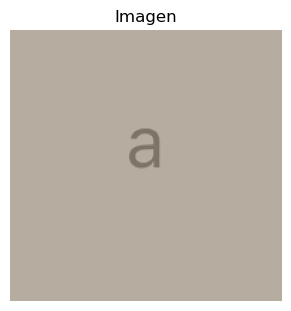

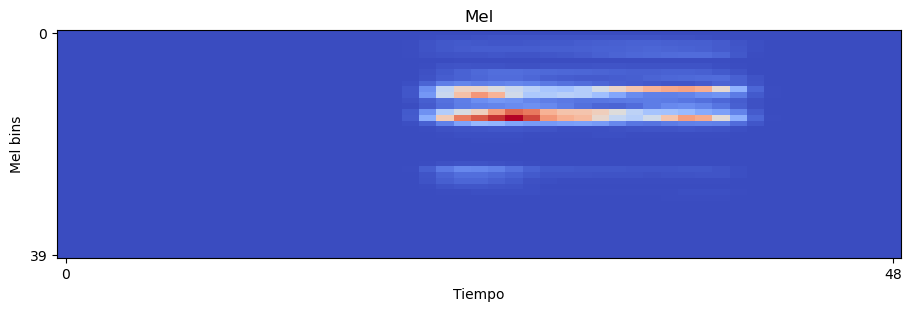

In [6]:
from cowaver.datasets import TinySpeakDataset, ImageMelDataset, RandomStride

dataset = ImageMelDataset(TinySpeakDataset(base_dir=tiny_letter_path / "val"), stride=RandomStride())

(image, mel), target = dataset[0]

plot_image(image)
plot_mel(mel)

In [12]:
from cowaver.datamodules import TinyMel
from cowaver.datasets import TinySpeakDataset, ImageMelDataset, RandomStride
from cowaver.utils import explorar_datos

letters_data = TinyMel(
    train_set=ImageMelDataset(TinySpeakDataset(base_dir=tiny_letter_path / "train"), stride=RandomStride()),
    test_set=ImageMelDataset(TinySpeakDataset(base_dir=tiny_letter_path / "val"))
)

def explore_tiny_mel(data, batch):
    (image, mel), label = batch
    fig = plt.figure(figsize=(9, 3), layout="constrained")
    axes = fig.subplot_mosaic([["image", "mel"]], gridspec_kw={"width_ratios": [1, 2]})
    plot_image(image, axes["image"])
    plot_mel(mel, axes["mel"])
    fig.suptitle(data.classes[label.item()])
    plt.show()

explorar_datos(letters_data, explore_tiny_mel)

In [11]:
words_data = TinyMel(
    train_set=ImageMelDataset(TinySpeakDataset(base_dir=tiny_kalulu_path / "train"), stride=RandomStride()),
    test_set=ImageMelDataset(TinySpeakDataset(base_dir=tiny_kalulu_path / "val"))
)

explorar_datos(words_data, explore_tiny_mel)

## Modules

### ImageToHorizontalFeatures

In [13]:
from cowaver.modules import ImageToHorizontalFeatures
from cowaver.utils import explorar_datos

encoder = ImageToHorizontalFeatures()

print(encoder)

def explore(data, batch):
    (x, _), y = batch
    with torch.no_grad():
        z = encoder(x)
    fig = plt.figure(figsize=(9, 2), layout="constrained")
    axes = fig.subplot_mosaic([["x", "z"]], gridspec_kw={"width_ratios": [1, 2]})
    plot_image(x, axes["x"])
    plot_activation(z, axes["z"])
    plt.show()
    
explorar_datos(letters_data, explore)

ImageToHorizontalFeatures(
  (cornet_z): DataParallel(
    (module): Sequential(
      (V1): CORblock_Z(
        (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V2): CORblock_Z(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V4): CORblock_Z(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (IT): CORblock_Z(
        (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

/Users/martin/miniconda3/envs/cowaver/lib/python3.12/site-packages/torch/serialization.py:1348: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


### TemporalAdapter

In [14]:
from cowaver.modules import ImageToHorizontalFeatures, TemporalAdapter
from cowaver.utils import explorar_datos

encoder = ImageToHorizontalFeatures()
adapter = TemporalAdapter()

print(adapter)

def explore(data, batch):
    (x, _), y = batch
    with torch.no_grad():
        z = encoder(x)
        r = adapter(z)
    fig = plt.figure(figsize=(9, 2), layout="constrained")
    axes = fig.subplot_mosaic([["z", "r"]], gridspec_kw={"width_ratios": [1, 2]})
    plot_activation(z, axes["z"])
    plot_activation(r, axes["r"])
    plt.show()
    
explorar_datos(letters_data, explore)

TemporalAdapter(
  (in_proj): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
  (blocks): Sequential(
    (0): ResidualTemporalBlock(
      (block): Sequential(
        (0): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU(inplace=True)
        (2): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
        (3): ReLU(inplace=True)
      )
    )
    (1): ResidualTemporalBlock(
      (block): Sequential(
        (0): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
        (1): ReLU(inplace=True)
        (2): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
        (3): ReLU(inplace=True)
      )
    )
    (2): ResidualTemporalBlock(
      (block): Sequential(
        (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): ReLU(inplace=True)
        (2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (3): ReLU(inplace=True)
      )
    )
  )
)


### HorizontalFeaturesToMel

In [15]:
from cowaver.modules import ImageToHorizontalFeatures, TemporalAdapter, HorizontalFeaturesToMel
from cowaver.utils import explorar_datos

encoder = ImageToHorizontalFeatures()
adapter = TemporalAdapter()
decoder = HorizontalFeaturesToMel()

print(decoder)

def explore(data, batch):
    (x, _), y = batch
    with torch.no_grad():
        z = encoder(x)
        r = adapter(z)
        y_hat = decoder(r)
    fig = plt.figure(figsize=(9, 2), layout="constrained")
    axes = fig.subplot_mosaic([["z", "y_hat"]], gridspec_kw={"width_ratios": [1, 2]})
    plot_activation(z, axes["z"])
    plot_mel(y_hat, axes["y_hat"])
    plt.show()
    
explorar_datos(letters_data, explore)

HorizontalFeaturesToMel(
  (in_proj): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
  (pre_blocks): Sequential(
    (0): ResidualTemporalBlock(
      (block): Sequential(
        (0): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU(inplace=True)
        (2): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
        (3): ReLU(inplace=True)
      )
    )
    (1): ResidualTemporalBlock(
      (block): Sequential(
        (0): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
        (1): ReLU(inplace=True)
        (2): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
        (3): ReLU(inplace=True)
      )
    )
  )
  (post_blocks): Sequential(
    (0): ResidualTemporalBlock(
      (block): Sequential(
        (0): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU(inplace=True)
        (2): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
        

### CoWaver

In [17]:
from cowaver.modules import CoWaver
from cowaver.utils import entrenar_red
from cowaver.checkpoints import cargar_checkpoint

cowaver = CoWaver()
print(CoWaver())

should_train = True
if should_train:
    train_history = entrenar_red(cowaver, letters_data, num_epochs=20)
    train_history = entrenar_red(cowaver, words_data, num_epochs=30, phase=2)
else:
    train_history = cargar_checkpoint(cowaver)

CoWaver(
  (visual_encoder): ImageToHorizontalFeatures(
    (cornet_z): DataParallel(
      (module): Sequential(
        (V1): CORblock_Z(
          (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
          (nonlin): ReLU(inplace=True)
          (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (output): Identity()
        )
        (V2): CORblock_Z(
          (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlin): ReLU(inplace=True)
          (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (output): Identity()
        )
        (V4): CORblock_Z(
          (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlin): ReLU(inplace=True)
          (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (output): Identity()
        )
        (IT): CORblock_Z(
         

KeyboardInterrupt: 

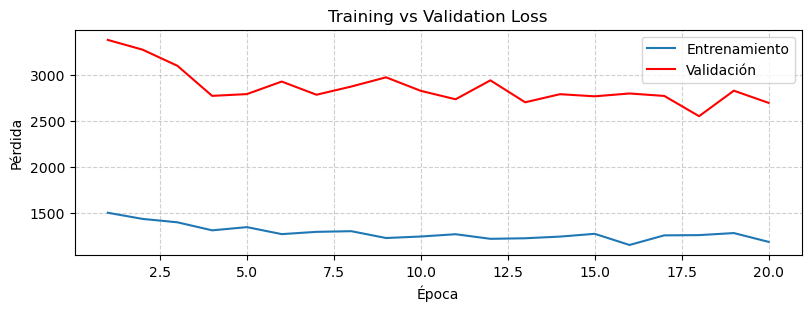

In [16]:
plot_train_history(train_history)

In [15]:
from cowaver.utils import explorar_red

def explore(net, batch):
    (x, y), _ = batch
    y_hat, z = net(x)
    
    fig = plt.figure(figsize=(9, 7), layout="constrained")
    axes = fig.subplot_mosaic([["x", "y"], ["z", "y_hat"]], gridspec_kw={"width_ratios": [1, 2]})
    
    plot_image(x.cpu(), ax=axes["x"])
    plot_mel(y.cpu(), ax=axes["y"])
    plot_activation(z, ax=axes["z"])
    plot_mel(y_hat.cpu(), ax=axes["y_hat"])
    
    plt.show()
    
explorar_red(cowaver, tiny_mel, explore)

TestResults(top1=0.038461538461538464, top3=0.11538461538461539, top5=0.15384615384615385)


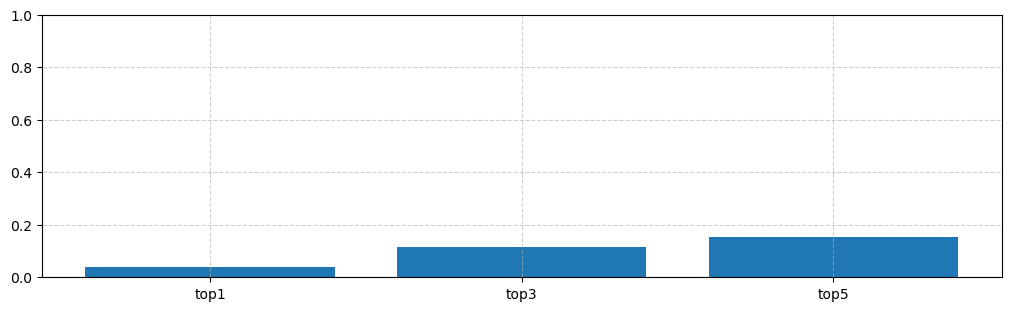

In [17]:
from cowaver.utils import evaluar_red

test_results = evaluar_red(cowaver, tiny_mel)
print(test_results)
plot_test_results(test_results)

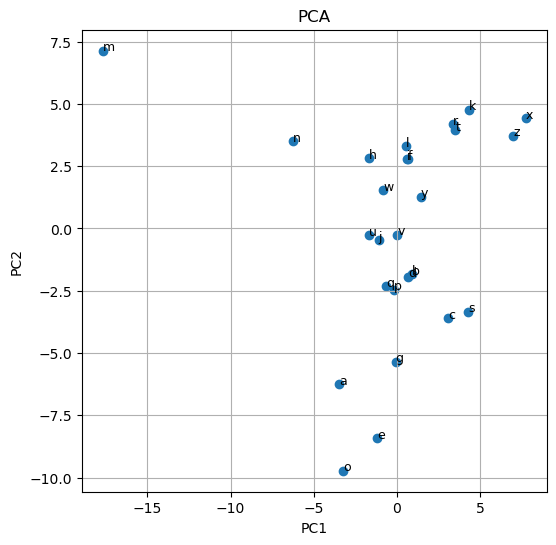

In [72]:
from cowaver.utils import make_image, pca

letters = TinySpeakDataset(base_dir=tiny_letter_path / "train").words

xs = []
for letter in letters:
    x = make_image(letter)
    xs.append(x)

X = torch.stack(xs, dim=0)

with torch.no_grad():
    y_hat, z = cowaver(X)

torch.manual_seed(42)
X_scores = pca(z.mean(dim=1))
plot_pca(X_scores, letters)

In [73]:
words_data = TinyMel(
    train_set=ImageMelDataset(TinySpeakDataset(base_dir=tiny_kalulu_path / "train"), stride=RandomStride()),
    test_set=ImageMelDataset(TinySpeakDataset(base_dir=tiny_kalulu_path / "val"))
)